Import library

In [1]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.chdir('../src')
os.getcwd()

'c:\\Users\\user\\Documents\\Projects\\6. Computer Vision\\Code\\computer-vision-playground\\src'

In [3]:
import opencv_utils

%load_ext autoreload
%autoreload 2

In [4]:
os.chdir('..')
os.getcwd()

'c:\\Users\\user\\Documents\\Projects\\6. Computer Vision\\Code\\computer-vision-playground'

# 1. Thresholding-Based Image Segmentation

Segmentation procedures are usually done using two approaches – 
- Detecting discontinuity in images and linking edges to form the region (known as edge-based segmenting)
- Detecting similarity among pixels based on intensity levels (known as threshold-based segmenting)

## Global Thresholding

### Simple Thresholding

- Select an initial estimate of the threshold T.
- Segment the image using T to form two groups G1 and G2: G1 consists of all pixels with intensity values > T, and G2 consists of all pixels - with intensity values ≤ T. 
- Compute the average intensity values m1 and m2 for groups G1 and G2.σ
- Compute the new value of the threshold T as T = (m1 + m2)/2
- Repeat steps 2 through 4 until the difference in the subsequent value of T is smaller than a pre-defined value δ.
- Segment the image as g(x,y) = 1 if f(x,y) > T and g(x,y) = 0 if f(x,y) ≤ T. 

This algorithm works well for images that have a clear valley in their histogram. The larger the value of δ, the smaller will be the number of iterations. The initial estimate of T can be made equal to the average pixel intensity of the entire image.

Different methods to use simple thresholding-

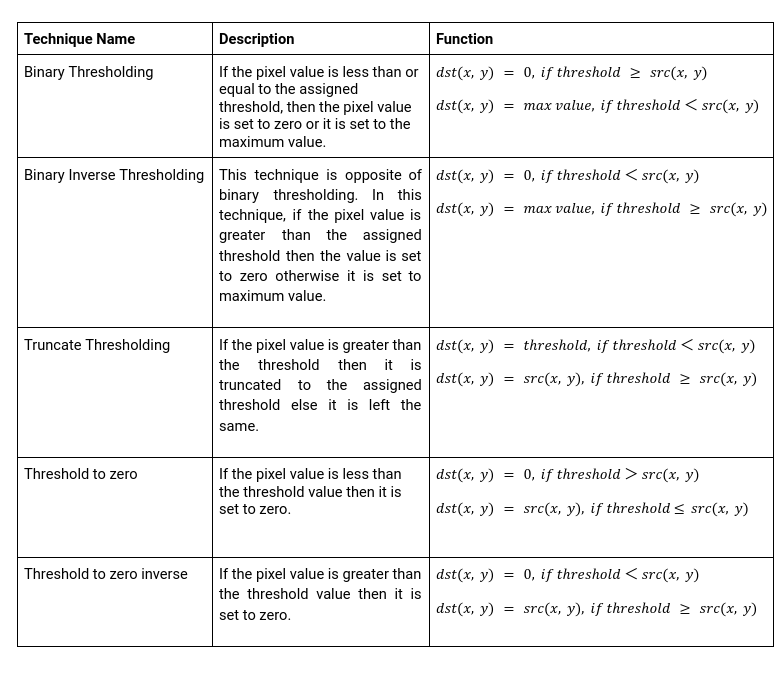

In [6]:
## Load image
img = opencv_utils.read_image("./data/raw/bird.jpg", cv.IMREAD_GRAYSCALE)

# Arguments of function cv2.threshold
# cv2.threshold(grayscaled image, threshold value, maximum value of pixel, type of threshold)
# Output is a tuple containg the threshold value and thresholded image

## Binary Thresholding

t, thresh_img = cv.threshold(img,70,255,cv.THRESH_BINARY)


## Binary Inverse Thresholding

t,thresh1_img = cv.threshold(img,70,255,cv.THRESH_BINARY_INV)

## Truncate Thresholding
rect,thresh2_img = cv.threshold(img,70,255,cv.THRESH_TRUNC)

## Threshold to zero
rect,thresh3_img = cv.threshold(img,70,255,cv.THRESH_TOZERO)

## Threshold to zero inverse
rect,thresh4_img = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)


The above simple global thresholding can be made optimum by using Otsu’s method. Otsu’s method is optimum in the sense that it maximizes the between-class variance.

### Otsu's thresholding

The idea in Otsu’s thresholding is to maximize the between-class variance. The between-class  variance can be defined as follows,

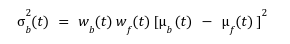

Here,  is the between-class variance of two classes – foreground class and background class. 

Let,  be the number of pixels in the background and foreground classes, respectively. n the total number of pixels in the image then,

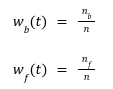

The mean of background class and foreground class is represented as-



Otsu’s algorithm calculates the between-class variance for all possible threshold values. The threshold with the highest between-class variance is taken as the optimal threshold value. Values less than the optimal threshold value falls into one class and other values fall into another class.

In [10]:
blur = cv.GaussianBlur(img,(5,5),0) #Applying Gaussian Blurr on image to get better threshold

t,thresh5_img = cv.threshold(blur,128,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

## Local Thresholding

### Variable Thresholding

There are broadly two different approaches to local thresholding. One approach is to partition the image into non-overlapping rectangles. Then the techniques of global thresholding or Otsu’s method are applied to each of the sub-images. Hence in the image partitioning technique, the methods of global thresholding are applied to each sub-image rectangle by assuming that each such rectangle is a separate image in itself. This approach is justified when the sub-image histogram properties are suitable (have two peaks with a wide valley in between) for the application of thresholding techniques but the entire image histogram is corrupted by noise and hence is not ideal for global thresholding.

The other approach is to compute a variable threshold at each point from the neighborhood pixel properties. Let us say that we have a neighborhood Sxy of a pixel having coordinates (x,y). If the mean and standard deviation of pixel intensities in this neighborhood be mxy and σxy , then the threshold at each point can be computed as:

$$
T_{xy} = a\sigma_{xy} + b m_{xy}
$$

where a and b are arbitrary constants. The above definition of the variable threshold is just an example. Other definitions can also be used according to the need. 

The segmented image is computed as:

$$
g(x, y) = 
\begin{cases} 
1 & \text{if } f(x, y) > T_{xy} \\
0 & \text{if } f(x, y) \le T_{xy}
\end{cases}
$$

Moving averages can also be used as thresholds. This technique of image thresholding is the most general one and can be applied to widely different cases. 

### Adaptive thresholding

Adaptive thresholding is a local thresholding technique. This technique considers each pixel and its neighborhood. The arithmetic mean or Gaussian mean of pixels intensity is commonly used to calculate the threshold of the neighborhood; then the threshold value is used to classify the pixel. In Gaussian mean, pixel value farther from the center of the region contributes less in finding the threshold of the region, while in arithmetic mean, all pixel values contribute equally. 

In [47]:
# Arithmatic Mean Adaptive thresholding
thresh6_img = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,5,4)

# Gaussian Mean Thresholding
thresh7_img = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,5,4)

C:\Users\user\AppData\Local\Temp\ipykernel_11636\1060494403.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 1200x800 with 0 Axes>

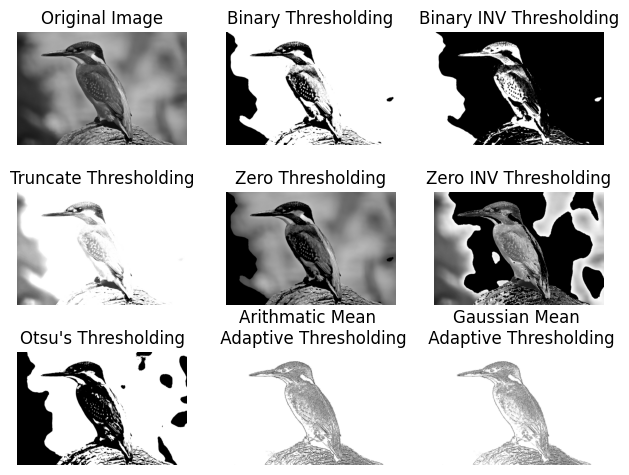

In [50]:
# Prepare titles and images for plotting
titles = ['Original Image', 'Binary Thresholding', 'Binary INV Thresholding',
          'Truncate Thresholding', 'Zero Thresholding', 'Zero INV Thresholding', "Otsu's Thresholding", "Arithmatic Mean \n Adaptive Thresholding", "Gaussian Mean \n Adaptive Thresholding"]
images = [img, thresh_img, thresh1_img, thresh2_img, thresh3_img, thresh4_img, thresh5_img, thresh6_img, thresh7_img]

# Plotting
plt.figure(figsize=(12, 8))
fig, axes = plt.subplots((len(titles)+2)//3, 3)

for i in range(len(titles)):
    
    axes[i//3, i%3].imshow(images[i], cmap='gray')
    axes[i//3, i%3].set_title(titles[i])
    axes[i//3, i%3].axis('off')

fig.tight_layout()
fig.show()

### Introduction to UNet: Deep learning Model for Image Segmentation

The UNet architecture was introduced for BioMedical Image segmentation by Olag Ronneberger et al. With this U-Net architecture, the segmentation of images can be computed with a modern GPU within small amounts of time. UNet uses the concept of a Fully Convolution Network along with little modification. This model helps to localize the object in an image and find the mask of that object.

The image below shows the architecture of U-Net. 

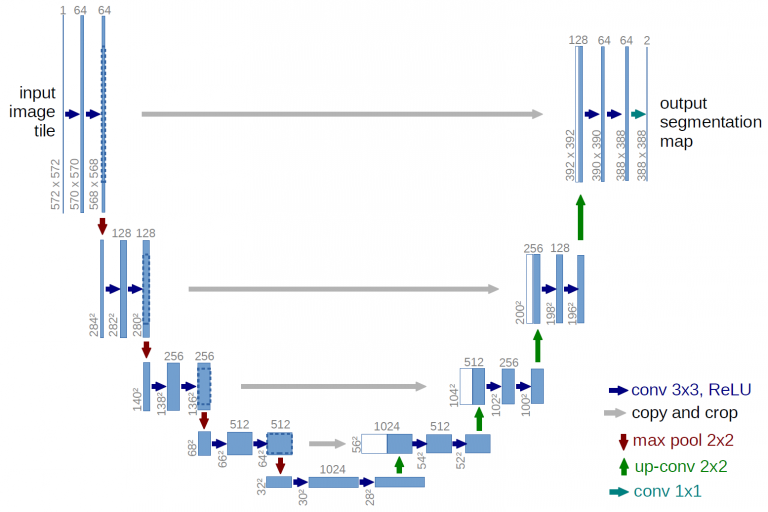

U-shaped architecture

- This model got its name from the U-shaped architecture.
- As we can see in the image, this architecture has two paths created as an encode-decoder network.
- We apply two convolution layers and max pooling layers in the left path.
- The ReLU activation function follows each convolution.
- On the right path, we apply transpose convolutions along with two regular convolutions